# Name - Swatej Sonawane
# Github Username - swatejsonawane18
# USC ID - 9314761761

# References

1. https://towardsdatascience.com/simple-and-multiple-linear-regression-in-python-c928425168f9
2. https://machinelearningmastery.com/how-to-use-statistics-to-identify-outliers-in-data/
3. https://towardsdatascience.com/polynomial-regression-bbe8b9d97491
4. https://www.codecademy.com/learn/linear-regression-mssp/modules/multiple-linear-regression-mssp/cheatsheet

In [1]:
import pandas as pd
import numpy as np
import math
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from numpy import percentile
import operator
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsRegressor


In [2]:
power_plant_data = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx',header=None)
print(power_plant_data)

          0      1        2      3       4
0        AT      V       AP     RH      PE
1     14.96  41.76  1024.07  73.17  463.26
2     25.18  62.96  1020.04  59.08  444.37
3      5.11   39.4  1012.16  92.14  488.56
4     20.86  57.32  1010.24  76.64  446.48
...     ...    ...      ...    ...     ...
9564  16.65  49.69  1014.01     91  460.03
9565  13.19  39.18  1023.67  66.78  469.62
9566  31.32  74.33  1012.92  36.48  429.57
9567  24.48  69.45  1013.86  62.39  435.74
9568   21.6  62.52  1017.23  67.87  453.28

[9569 rows x 5 columns]


In [3]:
headers = power_plant_data.iloc[0]
df  = pd.DataFrame(power_plant_data.values[1:], columns=headers)

# Q1 b i

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   AT      9568 non-null   object
 1   V       9568 non-null   object
 2   AP      9568 non-null   object
 3   RH      9568 non-null   object
 4   PE      9568 non-null   object
dtypes: object(5)
memory usage: 373.9+ KB


In [5]:
print('Number of Columns : 9568')
print('Number of Rows : 5')


Number of Columns : 9568
Number of Rows : 5


In [6]:
print('Rows represent :  hourly average ambient variables, Temperature (T), Ambient Pressure (AP), Relative Humidity (RH), Exhaust Vacuum (V) and net hourly electrical energy output (EP)')

Rows represent :  hourly average ambient variables, Temperature (T), Ambient Pressure (AP), Relative Humidity (RH), Exhaust Vacuum (V) and net hourly electrical energy output (EP)


In [7]:
print('Columns represent : hourly average measurement of Temperature (T), Ambient Pressure (AP), Relative Humidity (RH), Exhaust Vacuum (V) and net hourly electrical energy output (EP)')


Columns represent : hourly average measurement of Temperature (T), Ambient Pressure (AP), Relative Humidity (RH), Exhaust Vacuum (V) and net hourly electrical energy output (EP)


In [8]:
df

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.4,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.5,1009.23,96.62,473.9
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


# Q1 b ii

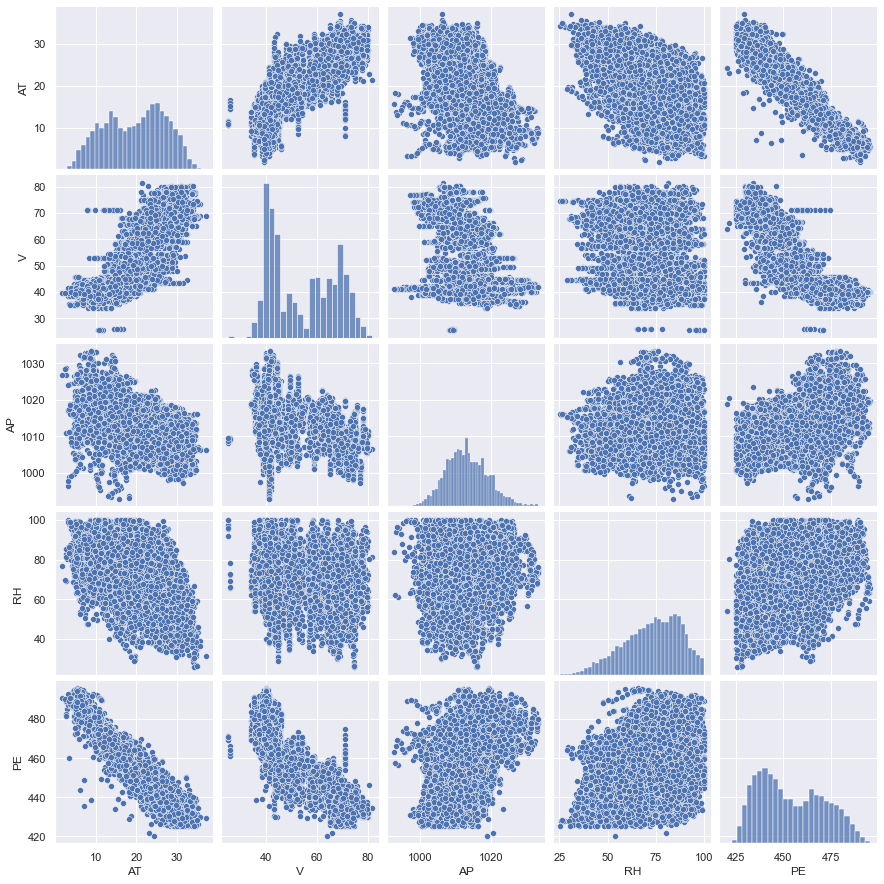

In [9]:
sns.set()
sns.pairplot(df, diag_kind='hist',vars=['AT', 'V', 'AP',
'RH', 'PE'])


Findings:
1. The Exhaust Vaccum (V) INCREASES as the Atmospheric Temperature (AT) INCREASES.
2. The Net Hourly Electrical Energy Output (PE) DECREASES as the Atmospheric Temperature (AT) INCREASES.
3. The Relative Humidity (RH) DECREASES as the Atmospheric Temperature (AT) INCREASES. 
4. The Net Hourly Electrical Energy Output (PE) DECREASES as the Exhaust Vaccum (V) INCREASES. 

In [10]:
df['AT'] = df.AT.astype(float)
df['V'] = df.V.astype(float)
df['AP'] = df.AP.astype(float)
df['RH'] = df.RH.astype(float)
df['PE'] = df.PE.astype(float)

# Q1 b iii

In [11]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


NOTE - Median is shown in the 50% row from the describe table

In [75]:
q25, q75 = percentile(df['AT'], 25), percentile(df['AT'], 75)
iqr = q75 - q25
print('Inter-Quartile Range for AT - ', iqr)
print('Range for AT - ', max(df['AT'])-min(df['AT']))
print()

q25, q75 = percentile(df['V'], 25), percentile(df['V'], 75)
iqr = q75 - q25
print('Inter-Quartile Range for V - ', iqr)
print('Range for V - ', max(df['V'])-min(df['V']))
print()

q25, q75 = percentile(df['AP'], 25), percentile(df['AP'], 75)
iqr = q75 - q25
print('Inter-Quartile Range for AP - ', iqr)
print('Range for AP - ', max(df['AP'])-min(df['AP']))
print()

q25, q75 = percentile(df['RH'], 25), percentile(df['RH'], 75)
iqr = q75 - q25
print('Inter-Quartile Range for RH - ', iqr)
print('Range for RH - ', max(df['RH'])-min(df['RH']))



Inter-Quartile Range for AT -  12.209999999999999
Range for AT -  35.3

Inter-Quartile Range for V -  24.800000000000004
Range for V -  56.2

Inter-Quartile Range for AP -  8.159999999999968
Range for AP -  40.40999999999997

Inter-Quartile Range for RH -  21.502499999999998
Range for RH -  74.6


# Q1 c

In [12]:
ilr_coeff=[]

In [13]:

lr = sm.OLS(df['PE'],sm.add_constant(df[['AT']], prepend=True)).fit()
ilr_coeff.append(np.array(lr.params)[1])
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:00   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.000     496.727     497.341
AT            -2.1713      0.007   -291.715      0.000      -2.186      -2.157
==============================================================================
Omnibus:                      417.457   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1117.844
Skew:                          -0.209   Prob(JB):                    1.83e-243
Kurtosis:                       4.621   Cond. No.                         59.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
print(ilr_coeff)

[-2.1713199585178002]


In [15]:
lr = sm.OLS(df['PE'],sm.add_constant(df[['V']], prepend=True)).fit()
ilr_coeff.append(np.array(lr.params)[1])
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:00   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015      0.378   1370.218      0.000     517.061     518.542
V             -1.1681      0.007   -172.402      0.000      -1.181      -1.155
==============================================================================
Omnibus:                       77.693   Durbin-Watson:                   2.007
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              109.571
Skew:                          -0.097   Prob(JB):                     1.61e-24
Kurtosis:                       3.487   Cond. No.                         245.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [16]:
print(ilr_coeff)

[-2.1713199585178002, -1.16813512655571]


In [17]:
lr = sm.OLS(df['PE'],sm.add_constant(df[['AP']], prepend=True)).fit()
ilr_coeff.append(np.array(lr.params)[1])
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:00   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610     25.459    -41.449      0.000   -1105.167   -1005.355
AP             1.4899      0.025     59.296      0.000       1.441       1.539
==============================================================================
Omnibus:                      525.438   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              612.290
Skew:                           0.616   Prob(JB):                    1.10e-133
Kurtosis:                       2.859   Cond. No.                     1.73e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.73e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [18]:
lr = sm.OLS(df['PE'],sm.add_constant(df[['RH']], prepend=True)).fit()
ilr_coeff.append(np.array(lr.params)[1])
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:01   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618      0.823    511.676      0.000     419.349     422.574
RH             0.4557      0.011     41.399      0.000       0.434       0.477
==============================================================================
Omnibus:                      772.278   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              319.245
Skew:                           0.231   Prob(JB):                     4.75e-70
Kurtosis:                       2.234   Cond. No.                         383.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

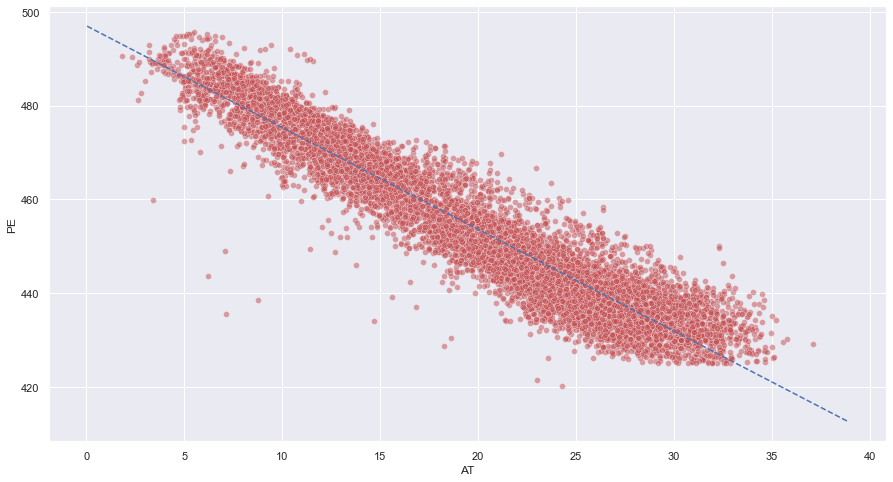

In [19]:
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111)

ax = sns.scatterplot(x="AT", y="PE", color='r', alpha=0.5, data=df)

x_vals = np.array(ax.get_xlim())
y_vals = 497.0341 - 2.1713 * x_vals
plt.plot(x_vals, y_vals, '--')

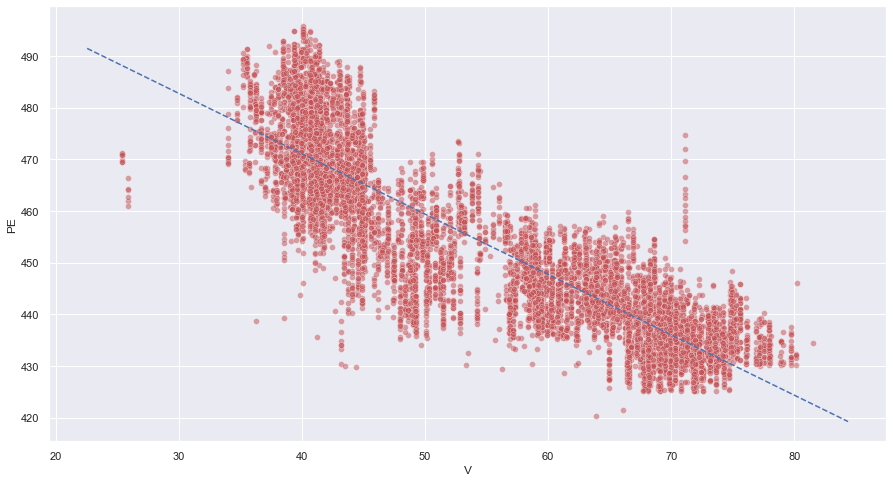

In [20]:
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111)

ax = sns.scatterplot(x="V", y="PE", color='r', alpha=0.5, data=df)

x_vals = np.array(ax.get_xlim())
y_vals = 517.8015 - 1.1681 * x_vals
plt.plot(x_vals, y_vals, '--')

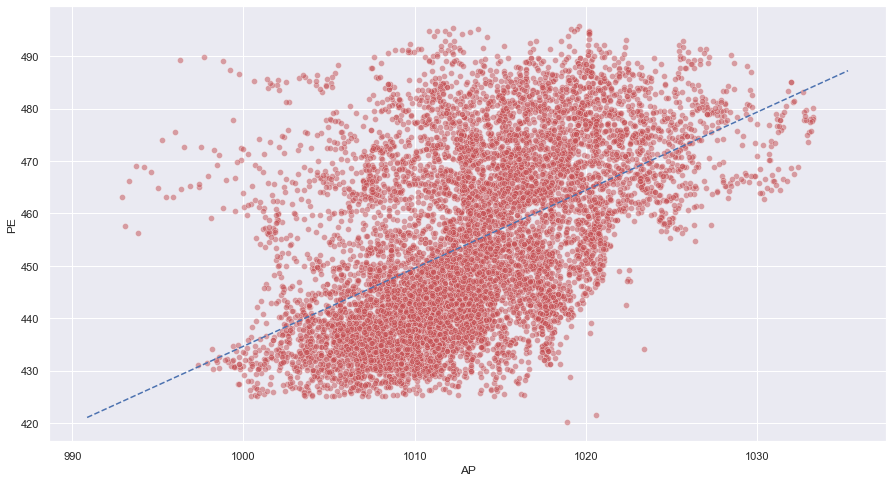

In [21]:
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111)

ax = sns.scatterplot(x="AP", y="PE", color='r', alpha=0.5, data=df)

x_vals = np.array(ax.get_xlim())
y_vals = -1055.2610 + 1.4899 * x_vals
plt.plot(x_vals, y_vals, '--')

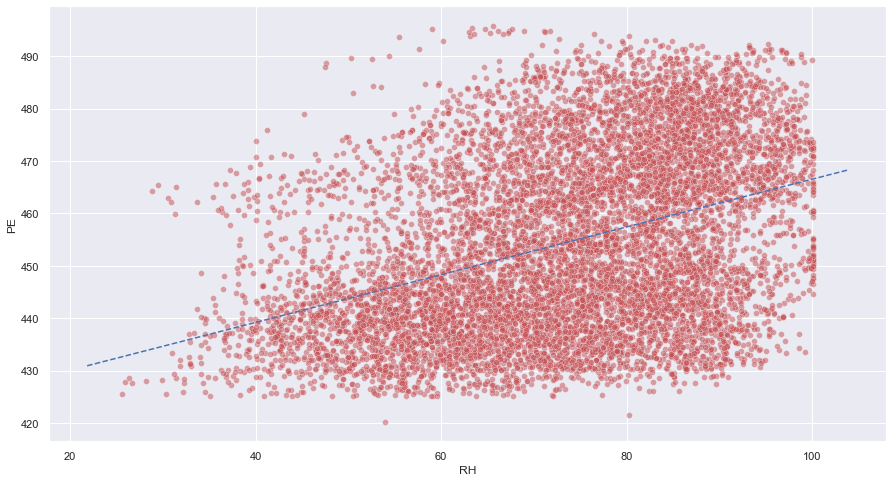

In [22]:
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111)

ax = sns.scatterplot(x="RH", y="PE", color='r', alpha=0.5, data=df)

x_vals = np.array(ax.get_xlim())
y_vals = 420.9618 + 0.4557 * x_vals
plt.plot(x_vals, y_vals, '--')

In which of the models is there a statistically significant
association between the predictor and the response?

Answer - 
1. There is statistically significant association between all the predictors and the response as the p-value is ZERO for all the linear models between individual predictors and the response.

In [23]:

q25, q75 = percentile(df['AT'], 25), percentile(df['AT'], 75)
iqr = q75 - q25
print('Percentiles: 25th=%.3f, 75th=%.3f, IQR=%.3f' % (q25, q75, iqr))

cut_off = iqr * 1.5
lower, upper = q25 - cut_off, q75 + cut_off

outliers = [x for x in df['AT'] if x < lower or x > upper]
print('Identified outliers: %d' % len(outliers))

outliers_removed = [x for x in df['AT'] if x >= lower and x <= upper]
print('Non-outlier observations: %d' % len(outliers_removed))

Percentiles: 25th=13.510, 75th=25.720, IQR=12.210
Identified outliers: 0
Non-outlier observations: 9568


In [24]:
q25, q75 = percentile(df['V'], 25), percentile(df['V'], 75)
iqr = q75 - q25
print('Percentiles: 25th=%.3f, 75th=%.3f, IQR=%.3f' % (q25, q75, iqr))

cut_off = iqr * 1.5
lower, upper = q25 - cut_off, q75 + cut_off

outliers = [x for x in df['V'] if x < lower or x > upper]
print('Identified outliers: %d' % len(outliers))

outliers_removed = [x for x in df['V'] if x >= lower and x <= upper]
print('Non-outlier observations: %d' % len(outliers_removed))

Percentiles: 25th=41.740, 75th=66.540, IQR=24.800
Identified outliers: 0
Non-outlier observations: 9568


In [25]:
q25, q75 = percentile(df['AP'], 25), percentile(df['AP'], 75)
iqr = q75 - q25
print('Percentiles: 25th=%.3f, 75th=%.3f, IQR=%.3f' % (q25, q75, iqr))

cut_off = iqr * 1.5
lower, upper = q25 - cut_off, q75 + cut_off

outliers = [x for x in df['AP'] if x < lower or x > upper]
print('Identified outliers: %d' % len(outliers))
print('Identified outliers: ',(outliers))

outliers_removed = [x for x in df['AP'] if x >= lower and x <= upper]
print('Non-outlier observations: %d' % len(outliers_removed))

Percentiles: 25th=1009.100, 75th=1017.260, IQR=8.160
Identified outliers: 88
Identified outliers:  [1030.46, 1033.25, 1030.18, 1031.1, 1029.65, 1029.8, 1033.04, 1033.3, 1032.67, 1033.08, 994.17, 995.88, 995.24, 1031.55, 996.32, 1029.6, 1030.3, 1031.5, 1030.94, 996.55, 1030.83, 1031.96, 996.35, 1031.01, 1030.77, 1032.98, 1032.93, 1031.33, 996.03, 1030.86, 1030.72, 1033.19, 1031.96, 1030.42, 1032.86, 1032.77, 1029.63, 1033.09, 1030.82, 1029.99, 1031.8, 1032.08, 993.31, 1033.14, 1029.54, 1032.88, 1029.7, 1030.81, 1030.0, 995.45, 1030.2, 1032.72, 1031.45, 1032.14, 1029.91, 995.02, 1031.14, 993.82, 1032.83, 1032.37, 1032.16, 1031.16, 1030.72, 1029.9, 994.6, 1030.1, 1029.61, 993.74, 1031.39, 1031.2, 1031.27, 1030.38, 1031.97, 1033.29, 1031.58, 1031.08, 993.11, 1031.75, 1029.54, 1029.7, 1031.21, 1031.34, 1030.68, 992.89, 1031.71, 1031.21, 1031.32, 1030.61]
Non-outlier observations: 9480


In [26]:
q25, q75 = percentile(df['RH'], 25), percentile(df['RH'], 75)
iqr = q75 - q25
print('Percentiles: 25th=%.3f, 75th=%.3f, IQR=%.3f' % (q25, q75, iqr))

cut_off = iqr * 1.5
lower, upper = q25 - cut_off, q75 + cut_off

outliers = [x for x in df['RH'] if x < lower or x > upper]
print('Identified outliers: %d' % len(outliers))
print('Identified outliers: ',(outliers))

outliers_removed = [x for x in df['RH'] if x >= lower and x <= upper]
print('Non-outlier observations: %d' % len(outliers_removed))

Percentiles: 25th=63.328, 75th=84.830, IQR=21.502
Identified outliers: 12
Identified outliers:  [25.89, 28.16, 29.43, 26.67, 29.86, 30.59, 25.56, 30.83, 28.81, 26.3, 30.34, 30.99]
Non-outlier observations: 9556


# Q1 d

In [27]:
lr_2 = sm.OLS(df['PE'],sm.add_constant(df[['AT','V','AP','RH']], prepend=True)).fit()
lr_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:02   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.000     435.500     473.718
AT            -1.9775      0.015   -129.342      0.000      -2.007      -1.948
V             -0.2339      0.007    -32.122      0.000      -0.248      -0.220
AP             0.0621      0.009      6.564      0.000       0.044       0.081
RH            -0.1581      0.004    -37.918      0.000      -0.166      -0.150
==============================================================================
Omnibus:                      892.002   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4086.777
Skew:                          -0.352   Prob(JB):                         0.00
Kurtosis:                       6.123   Cond. No.                     2.13e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.13e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

For which predictors can we reject the null hypothesis H0:βj= 0?

ANSWER - 

1. As the p-value is ZERO for ALL THE PREDICTORS we have to reject the null hypothesis for all the predictors. 

# Q1 e

In [28]:
mlr_coef=[]
mlr_coef=np.array(lr_2.params)
ilr_coeff= np.array(ilr_coeff)
print((mlr_coef))
print((ilr_coeff))

[ 4.54609274e+02 -1.97751311e+00 -2.33916423e-01  6.20829438e-02
 -1.58054103e-01]
[-2.17131996 -1.16813513  1.48987167  0.4556501 ]


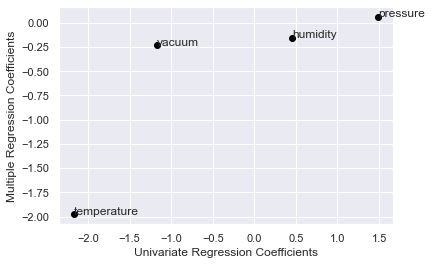

In [29]:
label=['temperature','vacuum','pressure','humidity']
y=mlr_coef[1:]
plt.plot(ilr_coeff,y, 'o', color='black')

plt.xlabel('Univariate Regression Coefficients')
plt.ylabel('Multiple Regression Coefficients')

for i, label in enumerate(label):
    plt.annotate(label, (ilr_coeff[i], y[i]))
    
plt.show()


# # Q1 f

In [30]:
model = sm.OLS.from_formula('PE ~ AT + np.power(AT,2) + np.power(AT,3)', df[['AT','PE']]).fit()

In [31]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:02   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         492.7281      0.673    732.248      0.000     491.409     494.047
AT                 -0.6103      0.124     -4.941      0.000      -0.852      -0.368
np.power(AT, 2)    -0.1251      0.007    -18.199      0.000      -0.139      -0.112
np.power(AT, 3)     0.0027      0.000     22.594      0.000       0.002       0.003
==============================================================================
Omnibus:                      648.041   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2767.059
Skew:                          -0.191   Prob(JB):                         0.00
Kurtosis:                       5.607   Cond. No.                     1.90e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.9e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

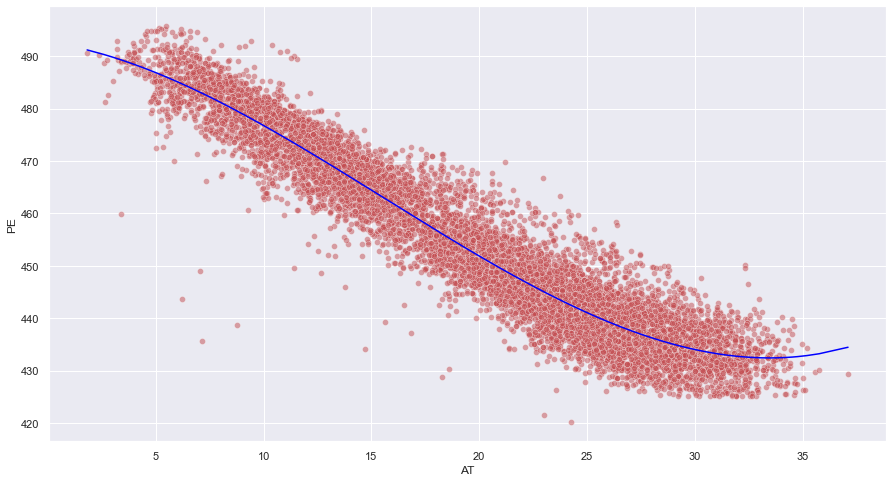

In [32]:

fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111)

ax = sns.scatterplot(x="AT", y="PE", color='r', alpha=0.5, data=df[['AT','PE']])

x_vals = df['AT']
y_vals = 492.7281 - (0.6103 * x_vals) - (0.1251 * np.square(x_vals)) + (0.0027 * np.power(x_vals, 3))


sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x_vals,model.fittedvalues), key=sort_axis)
x, y_poly_pred = zip(*sorted_zip)
plt.plot(x, y_poly_pred, color='blue')
plt.show()

In [33]:
model = sm.OLS.from_formula('PE ~ V + np.power(V,2) + np.power(V,3)', df[['V','PE']]).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:02   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        554.1468      9.151     60.557      0.000     536.209     572.084
V                 -2.1444      0.509     -4.214      0.000      -3.142      -1.147
np.power(V, 2)    -0.0027      0.009     -0.294      0.768      -0.021       0.015
np.power(V, 3)     0.0001   5.45e-05      2.465      0.014    2.75e-05       0.000
==============================================================================
Omnibus:                      160.101   Durbin-Watson:                   2.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              279.778
Skew:                          -0.125   Prob(JB):                     1.77e-61
Kurtosis:                       3.800   Cond. No.                     2.47e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.47e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

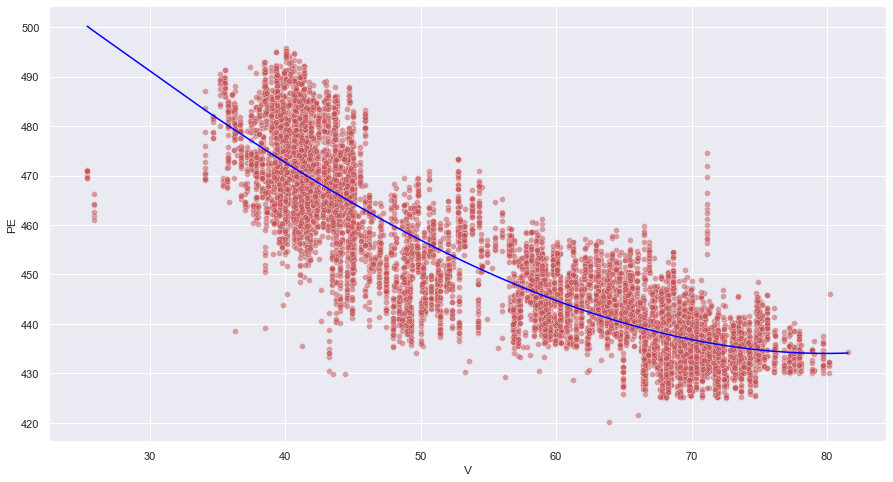

In [34]:
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111)

ax = sns.scatterplot(x="V", y="PE", color='r', alpha=0.5, data=df[['V','PE']])

x_vals = df['V']
y_vals = 554.1468 - (2.1444 * x_vals) - (0.0027 * np.square(x_vals)) + (0.0001 * np.power(x_vals, 3))


sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x_vals,model.fittedvalues), key=sort_axis)
x, y_poly_pred = zip(*sorted_zip)
plt.plot(x, y_poly_pred, color='blue')
plt.show()

In [35]:
model = sm.OLS.from_formula('PE ~ AP + np.power(AP,2) + np.power(AP,3)', df[['AP','PE']]).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1813.
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:03   Log-Likelihood:                -39184.
No. Observations:                9568   AIC:                         7.837e+04
Df Residuals:                    9565   BIC:                         7.840e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0747      0.009      8.415      0.000       0.057       0.092
AP                 25.2556      3.001      8.415      0.000      19.372      31.139
np.power(AP, 2)    -0.0500      0.006     -8.439      0.000      -0.062      -0.038
np.power(AP, 3)  2.514e-05   2.92e-06      8.613      0.000    1.94e-05    3.09e-05
==============================================================================
Omnibus:                      556.766   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              640.319
Skew:                           0.621   Prob(JB):                    9.05e-140
Kurtosis:                       2.751   Cond. No.                     2.12e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.12e+15. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

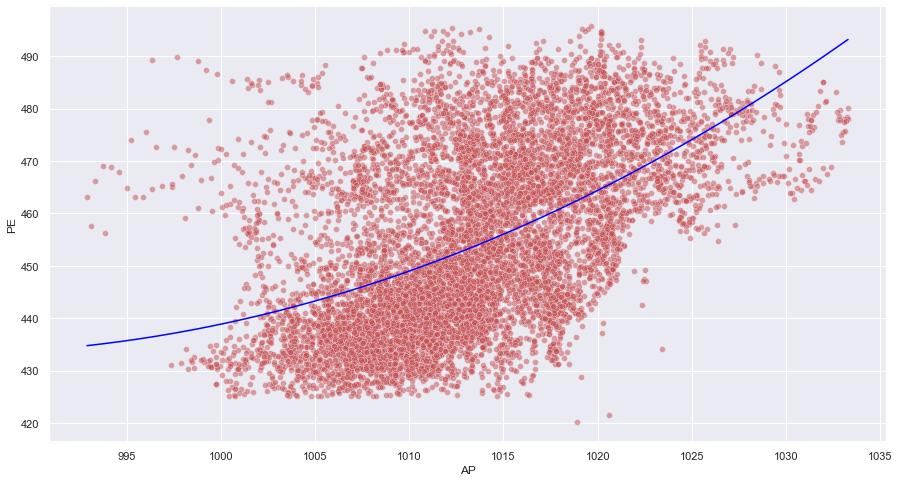

In [36]:
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111)

ax = sns.scatterplot(x="AP", y="PE", color='r', alpha=0.5, data=df[['AP','PE']])

x_vals = df['AP']
y_vals = 0.0747 + (25.2556 * x_vals) - (0.05 * np.square(x_vals)) + (0.00002514 * np.power(x_vals, 3))

sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x_vals,model.fittedvalues), key=sort_axis)
x, y_poly_pred = zip(*sorted_zip)
plt.plot(x, y_poly_pred, color='blue')
plt.show()

In [37]:
model = sm.OLS.from_formula('PE ~ RH + np.power(RH,2) + np.power(RH,3)', df[['RH','PE']]).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:03   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         468.4135     10.545     44.422      0.000     447.744     489.083
RH                 -1.7292      0.486     -3.557      0.000      -2.682      -0.776
np.power(RH, 2)     0.0321      0.007      4.433      0.000       0.018       0.046
np.power(RH, 3)    -0.0002   3.51e-05     -4.340      0.000      -0.000   -8.34e-05
==============================================================================
Omnibus:                      707.867   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              302.057
Skew:                           0.223   Prob(JB):                     2.56e-66
Kurtosis:                       2.253   Cond. No.                     3.26e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.26e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

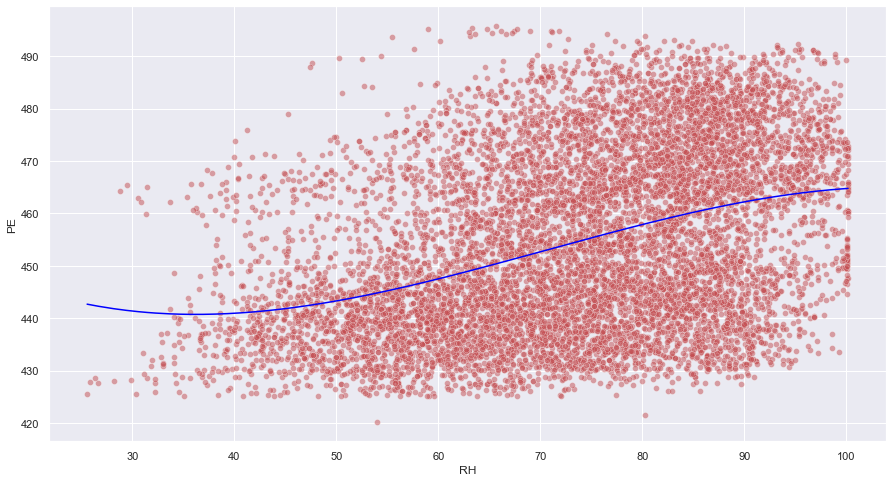

In [38]:
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111)

ax = sns.scatterplot(x="RH", y="PE", color='r', alpha=0.5, data=df[['RH','PE']])

x_vals = df['RH']
y_vals = 468.4135 - (1.7292 * x_vals) + (0.0321 * np.square(x_vals)) - (0.0002 * np.power(x_vals, 3))


sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x_vals,model.fittedvalues), key=sort_axis)
x, y_poly_pred = zip(*sorted_zip)
plt.plot(x, y_poly_pred, color='blue')
plt.show()

Is there evidence of nonlinear association between any of the predictors and the response?

ANSWER - 

1. We can see that there is nonlinear association as the predictors, AT^2, AT^3, V^3, AP^2, AP^3, RH^2, RH^3 have p-value less than 0.05

# Q1 g

In [39]:
model = sm.OLS.from_formula('PE ~ AT + V + AP + RH +  np.power(AT,2) + AT:V + AT:AP + AT:RH + np.power(V,2) + V:AP + V:RH +  np.power(AP,2) + AP:RH +  np.power(RH,2) ', df).fit()

In [40]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.030e+04
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:03   Log-Likelihood:                -27431.
No. Observations:                9568   AIC:                         5.489e+04
Df Residuals:                    9553   BIC:                         5.500e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -7503.7323   1207.276     -6.215      0.000   -9870.250   -5137.214
AT                 -5.7969      3.092     -1.875      0.061     -11.858       0.264
V                  -3.0443      1.498     -2.033      0.042      -5.980      -0.109
AP                 15.6284      2.341      6.677      0.000      11.040      20.216
RH                  3.9194      0.879      4.458      0.000       2.196       5.643
np.power(AT, 2)     0.0163      0.003      5.307      0.000       0.010       0.022
AT:V                0.0120      0.003      4.463      0.000       0.007       0.017
AT:AP               0.0031      0.003      1.037      0.300      -0.003       0.009
AT:RH              -0.0061      0.001     -4.056      0.000      -0.009      -0.003
np.power(V, 2)     -0.0013      0.001     -1.606      0.108      -0.003       0.000
V:AP                0.0026      0.001      1.765      0.078      -0.000       0.005
V:RH                0.0005      0.001      0.765      0.444      -0.001       0.002
np.power(AP, 2)    -0.0076      0.001     -6.706      0.000      -0.010      -0.005
AP:RH              -0.0036      0.001     -4.262      0.000      -0.005      -0.002
np.power(RH, 2)    -0.0019      0.000     -7.256      0.000      -0.002      -0.001
==============================================================================
Omnibus:                     1629.849   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11134.924
Skew:                          -0.642   Prob(JB):                         0.00
Kurtosis:                       8.127   Cond. No.                     2.86e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.86e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

State whether any interaction terms are statistically significant.

ANSWER - 

1. From the summary table above we can see that V, AP, RH, AT-AT, AT-V, AT-RH, AP-AP, AP-RH, RH-RH have p-value LESS THAN 0.05 so we can conclude that these terms are statistically significant.  

# Q1 h

In [41]:
X_train, X_test, y_train, y_test = train_test_split(df, df['PE'], test_size=0.3, random_state=42)

In [42]:
model_regression_train = sm.OLS.from_formula('PE ~ AT + V + AP + RH', X_train).fit()

In [43]:
model_regression_train.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.194e+04
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:03   Log-Likelihood:                -19630.
No. Observations:                6697   AIC:                         3.927e+04
Df Residuals:                    6692   BIC:                         3.930e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    467.8414     11.502     40.673      0.000     445.293     490.390
AT            -2.0044      0.018   -110.340      0.000      -2.040      -1.969
V             -0.2271      0.009    -26.301      0.000      -0.244      -0.210
AP             0.0493      0.011      4.416      0.000       0.027       0.071
RH            -0.1600      0.005    -32.337      0.000      -0.170      -0.150
==============================================================================
Omnibus:                      703.168   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3512.957
Skew:                          -0.390   Prob(JB):                         0.00
Kurtosis:                       6.461   Cond. No.                     2.11e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.11e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [44]:
print("TRAIN - ")
print("Residual Squared Error",model_regression_train.mse_resid)
print("Total Mean Squared Error",model_regression_train.mse_total)

TRAIN - 
Residual Squared Error 20.596216922186503
Total Mean Squared Error 290.4710854761418


In [45]:
model_regression_test = sm.OLS.from_formula('PE ~ AT + V + AP + RH', X_test).fit()

In [46]:
model_regression_test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     9231.
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:03   Log-Likelihood:                -8452.0
No. Observations:                2871   AIC:                         1.691e+04
Df Residuals:                    2866   BIC:                         1.694e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    422.3134     18.341     23.025      0.000     386.350     458.277
AT            -1.9136      0.028    -67.661      0.000      -1.969      -1.858
V             -0.2505      0.014    -18.512      0.000      -0.277      -0.224
AP             0.0933      0.018      5.249      0.000       0.058       0.128
RH            -0.1533      0.008    -19.822      0.000      -0.169      -0.138
==============================================================================
Omnibus:                      192.382   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              683.584
Skew:                          -0.260   Prob(JB):                    3.64e-149
Kurtosis:                       5.333   Cond. No.                     2.17e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.17e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [47]:
print("TEST - ")
print("Residual Squared Error",model_regression_test.mse_resid)
print("Total Mean Squared Error",model_regression_test.mse_total)

TEST - 
Residual Squared Error 21.152093410145877
Total Mean Squared Error 293.261789275089


In [48]:
model_nonlinear_all_train = sm.OLS.from_formula('PE ~ AT + V + AP + RH + np.power(AT,2) + np.power(AT,3) + np.power(V,2) + np.power(V,3) + np.power(AP,2) + np.power(AP,3) + np.power(RH,2) + np.power(RH,3) + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH', X_train).fit()

In [49]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.030e+04
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:04   Log-Likelihood:                -27431.
No. Observations:                9568   AIC:                         5.489e+04
Df Residuals:                    9553   BIC:                         5.500e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -7503.7323   1207.276     -6.215      0.000   -9870.250   -5137.214
AT                 -5.7969      3.092     -1.875      0.061     -11.858       0.264
V                  -3.0443      1.498     -2.033      0.042      -5.980      -0.109
AP                 15.6284      2.341      6.677      0.000      11.040      20.216
RH                  3.9194      0.879      4.458      0.000       2.196       5.643
np.power(AT, 2)     0.0163      0.003      5.307      0.000       0.010       0.022
AT:V                0.0120      0.003      4.463      0.000       0.007       0.017
AT:AP               0.0031      0.003      1.037      0.300      -0.003       0.009
AT:RH              -0.0061      0.001     -4.056      0.000      -0.009      -0.003
np.power(V, 2)     -0.0013      0.001     -1.606      0.108      -0.003       0.000
V:AP                0.0026      0.001      1.765      0.078      -0.000       0.005
V:RH                0.0005      0.001      0.765      0.444      -0.001       0.002
np.power(AP, 2)    -0.0076      0.001     -6.706      0.000      -0.010      -0.005
AP:RH              -0.0036      0.001     -4.262      0.000      -0.005      -0.002
np.power(RH, 2)    -0.0019      0.000     -7.256      0.000      -0.002      -0.001
==============================================================================
Omnibus:                     1629.849   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11134.924
Skew:                          -0.642   Prob(JB):                         0.00
Kurtosis:                       8.127   Cond. No.                     2.86e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.86e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [50]:
print("TRAIN - ")
print("Residual Squared Error",model_nonlinear_all_train.mse_resid)
print("Total Mean Squared Error",model_nonlinear_all_train.mse_total)

TRAIN - 
Residual Squared Error 17.606562966087125
Total Mean Squared Error 290.4710854761418


In [51]:
model_nonlinear_all_test = sm.OLS.from_formula('PE ~ AT + V + AP + RH + np.power(AT,2) + np.power(AT,3) + np.power(V,2) + np.power(V,3) + np.power(AP,2) + np.power(AP,3) + np.power(RH,2) + np.power(RH,3) + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH', X_test).fit()

In [52]:
model_nonlinear_all_test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     2552.
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:04   Log-Likelihood:                -8230.1
No. Observations:                2871   AIC:                         1.650e+04
Df Residuals:                    2853   BIC:                         1.660e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0216      0.007     -3.171      0.002      -0.035      -0.008
AT                 -0.7977      5.900     -0.135      0.892     -12.367      10.771
V                  -4.4490      2.809     -1.584      0.113      -9.958       1.060
AP                 -7.3089      2.302     -3.175      0.002     -11.823      -2.795
RH                  4.6571      1.708      2.726      0.006       1.308       8.007
np.power(AT, 2)    -0.0437      0.012     -3.636      0.000      -0.067      -0.020
np.power(AT, 3)     0.0011      0.000      5.025      0.000       0.001       0.002
np.power(V, 2)     -0.0442      0.008     -5.231      0.000      -0.061      -0.028
np.power(V, 3)      0.0002   4.99e-05      4.970      0.000       0.000       0.000
np.power(AP, 2)     0.0156      0.004      3.513      0.000       0.007       0.024
np.power(AP, 3) -7.865e-06   2.15e-06     -3.652      0.000   -1.21e-05   -3.64e-06
np.power(RH, 2)    -0.0044      0.004     -1.190      0.234      -0.012       0.003
np.power(RH, 3)  1.058e-05   1.75e-05      0.603      0.547   -2.38e-05     4.5e-05
AT:V                0.0125      0.005      2.495      0.013       0.003       0.022
AT:AP              -0.0008      0.006     -0.141      0.888      -0.012       0.010
AT:RH              -0.0066      0.003     -2.325      0.020      -0.012      -0.001
V:AP                0.0063      0.003      2.275      0.023       0.001       0.012
V:RH                0.0017      0.001      1.411      0.158      -0.001       0.004
AP:RH              -0.0042      0.002     -2.589      0.010      -0.007      -0.001
==============================================================================
Omnibus:                      438.037   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2731.944
Skew:                          -0.565   Prob(JB):                         0.00
Kurtosis:                       7.643   Cond. No.                     2.17e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.17e+15. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [53]:
print("TEST - ")
print("Residual Squared Error",model_nonlinear_all_test.mse_resid)
print("Total Mean Squared Error",model_nonlinear_all_test.mse_total)

TEST - 
Residual Squared Error 18.205143177585363
Total Mean Squared Error 293.261789275089


In [54]:
i=0
significant_parameters=[]
for key, value in model.params.iteritems():
    if model.pvalues[i]<0.05:
        significant_parameters.append(key)
    i=i+1

In [55]:
significant_parameters

['Intercept',
 'V',
 'AP',
 'RH',
 'np.power(AT, 2)',
 'AT:V',
 'AT:RH',
 'np.power(AP, 2)',
 'AP:RH',
 'np.power(RH, 2)']

In [56]:
model_nonlinear_train = sm.OLS.from_formula('PE ~ AT + AP + RH + np.power(AT,2) + np.power(AT,3) + np.power(V,2) + np.power(V,3) + np.power(AP,2) + np.power(AP,3) + AT:RH + AP:RH', X_train).fit()

In [57]:
model_nonlinear_train.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.018e+04
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:04   Log-Likelihood:                -19163.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.842e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0315      0.003     -9.903      0.000      -0.038      -0.025
AT                 -1.8652      0.140    -13.347      0.000      -2.139      -1.591
AP                -10.6675      1.077     -9.904      0.000     -12.779      -8.556
RH                  4.8283      0.730      6.618      0.000       3.398       6.258
np.power(AT, 2)    -0.0298      0.008     -3.958      0.000      -0.045      -0.015
np.power(AT, 3)     0.0010      0.000      7.651      0.000       0.001       0.001
np.power(V, 2)     -0.0063      0.001    -10.257      0.000      -0.007      -0.005
np.power(V, 3)   4.423e-05   6.79e-06      6.514      0.000    3.09e-05    5.75e-05
np.power(AP, 2)     0.0221      0.002     10.395      0.000       0.018       0.026
np.power(AP, 3) -1.092e-05   1.05e-06    -10.410      0.000    -1.3e-05   -8.86e-06
AT:RH              -0.0015      0.001     -2.098      0.036      -0.003   -9.75e-05
AP:RH              -0.0049      0.001     -6.773      0.000      -0.006      -0.003
==============================================================================
Omnibus:                     1196.305   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8291.162
Skew:                          -0.675   Prob(JB):                         0.00
Kurtosis:                       8.281   Cond. No.                     2.20e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.2e+15. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [58]:
print("Train:")
print("Residual Squared Error",model_nonlinear_train.mse_resid)
print("Total Mean Squared Error",model_nonlinear_train.mse_total)

Train:
Residual Squared Error 17.930601510916397
Total Mean Squared Error 290.4710854761418


In [59]:
model_nonlinear_test = sm.OLS.from_formula('PE ~ AT + AP + RH + np.power(AT,2) + np.power(AT,3) + np.power(V,2) + np.power(V,3) + np.power(AP,2) + np.power(AP,3) + AT:RH + AP:RH', X_test).fit()

In [60]:
model_nonlinear_test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     4261.
Date:                Fri, 10 Feb 2023   Prob (F-statistic):               0.00
Time:                        18:16:04   Log-Likelihood:                -8257.5
No. Observations:                2871   AIC:                         1.654e+04
Df Residuals:                    2860   BIC:                         1.660e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0296      0.005     -5.955      0.000      -0.039      -0.020
AT                 -1.6915      0.210     -8.060      0.000      -2.103      -1.280
AP                -10.0065      1.680     -5.955      0.000     -13.301      -6.712
RH                  3.8879      1.160      3.352      0.001       1.614       6.162
np.power(AT, 2)    -0.0414      0.011     -3.613      0.000      -0.064      -0.019
np.power(AT, 3)     0.0013      0.000      6.096      0.000       0.001       0.002
np.power(V, 2)     -0.0053      0.001     -5.668      0.000      -0.007      -0.003
np.power(V, 3)   3.114e-05   1.05e-05      2.979      0.003    1.06e-05    5.16e-05
np.power(AP, 2)     0.0208      0.003      6.285      0.000       0.014       0.027
np.power(AP, 3) -1.031e-05   1.63e-06     -6.310      0.000   -1.35e-05   -7.11e-06
AT:RH              -0.0005      0.001     -0.462      0.644      -0.003       0.002
AP:RH              -0.0039      0.001     -3.453      0.001      -0.006      -0.002
==============================================================================
Omnibus:                      408.931   Durbin-Watson:                   2.021
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2280.505
Skew:                          -0.549   Prob(JB):                         0.00
Kurtosis:                       7.226   Cond. No.                     2.12e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.12e+15. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [61]:
print("Test:")
print("Residual Mean Squared Error",model_nonlinear_test.mse_resid)
print("Total Mean Squared Error",model_nonlinear_test.mse_total)

Test:
Residual Mean Squared Error 18.50954670857419
Total Mean Squared Error 293.261789275089


In [62]:
print('REPORT - ')
print()
print('Regression model with all predictors -')
print()
print("TRAIN - ")
print("Residual Squared Error",model_regression_train.mse_resid)
print("Total Mean Squared Error",model_regression_train.mse_total)

print("TEST - ")
print("Residual Squared Error",model_regression_test.mse_resid)
print("Total Mean Squared Error",model_regression_test.mse_total)

print()
print('Regression model with all possible interaction terms and quadratic nonlinearities -')
print()
print("TRAIN - ")
print("Residual Squared Error",model_nonlinear_all_train.mse_resid)
print("Total Mean Squared Error",model_nonlinear_all_train.mse_total)

print("TEST - ")
print("Residual Squared Error",model_nonlinear_all_test.mse_resid)
print("Total Mean Squared Error",model_nonlinear_all_test.mse_total)
print()
print('Regression model with SIGNIFICANT interaction terms and quadratic nonlinearities -')
print()
print("TRAIN - ")
print("Residual Squared Error",model_nonlinear_train.mse_resid)
print("Total Mean Squared Error",model_nonlinear_train.mse_total)

print("TEST - ")
print("Residual Squared Error",model_nonlinear_test.mse_resid)
print("Total Mean Squared Error",model_nonlinear_test.mse_total)

REPORT - 

Regression model with all predictors -

TRAIN - 
Residual Squared Error 20.596216922186503
Total Mean Squared Error 290.4710854761418
TEST - 
Residual Squared Error 21.152093410145877
Total Mean Squared Error 293.261789275089

Regression model with all possible interaction terms and quadratic nonlinearities -

TRAIN - 
Residual Squared Error 17.606562966087125
Total Mean Squared Error 290.4710854761418
TEST - 
Residual Squared Error 18.205143177585363
Total Mean Squared Error 293.261789275089

Regression model with SIGNIFICANT interaction terms and quadratic nonlinearities -

TRAIN - 
Residual Squared Error 17.930601510916397
Total Mean Squared Error 290.4710854761418
TEST - 
Residual Squared Error 18.50954670857419
Total Mean Squared Error 293.261789275089


# Q1 i

In [63]:
X_train, X_test, y_train, y_test = train_test_split(df[['AT','V','AP','RH']], df['PE'], test_size=0.3, random_state=42)

test_error=[]
train_error=[]
k_value=[]
best_test_error = float('inf')
best_train_error = float('inf')
k_best=0

for i in range(1, 101, 1):
    knn = KNeighborsRegressor(n_neighbors=i)
    knn.fit(X_train, y_train)
    local_test_error = 1-knn.score(X_test, y_test)
    local_train_error = 1-knn.score(X_train, y_train)
    test_error.append(local_test_error)
    train_error.append(local_train_error)
    k_value.append(i)
    if(local_test_error<best_test_error):
        k_best=i
        best_test_error=local_test_error
    
    
print("The best value of k:",k_best)


The best value of k: 5


In [64]:
raw_knn_best_test_error = best_test_error
print(raw_knn_best_test_error)

0.05364592369711796


In [65]:
reciprocal_k=[]
for i in k_value:
    reciprocal_k.append(1/i)

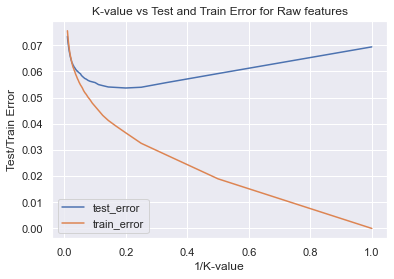

In [66]:
plt.plot(reciprocal_k, test_error, label='test_error')
plt.legend(loc="best")


plt.plot(reciprocal_k, train_error, label='train_error')
plt.legend(loc="best")

plt.title('K-value vs Test and Train Error for Raw features')
plt.xlabel('1/K-value')
plt.ylabel('Test/Train Error')

plt.show()

In [67]:

X_train, X_test, y_train, y_test = train_test_split(df[['AT','V','AP','RH']], df['PE'], test_size=0.3, random_state=42)

norm = MinMaxScaler().fit(X_train)

normalized_train_X  = norm.transform(X_train)
normalized_test_X = norm.transform(X_test)


In [68]:
headers=['AT','V','AP','RH']
df_X_train_norm = pd.DataFrame(columns = headers, data = normalized_train_X)
df_X_test_norm = pd.DataFrame(columns = headers, data = normalized_test_X)


In [69]:

test_error=[]
train_error=[]
k_value=[]
best_test_error = float('inf')
best_train_error = float('inf')
k_best=0

for i in range(1, 101, 1):
    knn = KNeighborsRegressor(n_neighbors=i)
    knn.fit(df_X_train_norm, y_train)
    local_test_error = 1-knn.score(df_X_test_norm, y_test)
    local_train_error = 1-knn.score(df_X_train_norm, y_train)
    test_error.append(local_test_error)
    train_error.append(local_train_error)
    k_value.append(i)
    if(local_test_error<best_test_error):
        k_best=i
        best_test_error=local_test_error
    
    
print("The best value of k:",k_best)

The best value of k: 4


In [70]:
normalized_knn_best_test_error = best_test_error
print(normalized_knn_best_test_error)

0.04874932061664594


In [71]:
reciprocal_k=[]
for i in k_value:
    reciprocal_k.append(1/i)

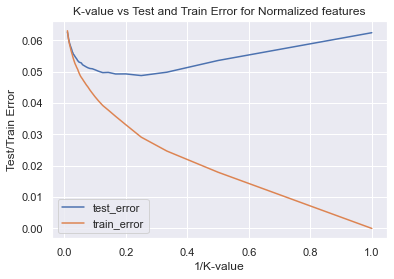

In [72]:
plt.plot(reciprocal_k, test_error, label='test_error')
plt.legend(loc="best")


plt.plot(reciprocal_k, train_error, label='train_error')
plt.legend(loc="best")

plt.title('K-value vs Test and Train Error for Normalized features')
plt.xlabel('1/K-value')
plt.ylabel('Test/Train Error')

plt.show()

# Q1 j

In [73]:
print('RESULTS: ')
print('Best Test Error for KNN Regression with RAW features: ', raw_knn_best_test_error)
print('Best Test Error for KNN Regression with NORMALIZED features: ', normalized_knn_best_test_error)
print('Best Test Error Linear Regression', 1-model_regression_test.rsquared )

RESULTS: 
Best Test Error for KNN Regression with RAW features:  0.05364592369711796
Best Test Error for KNN Regression with NORMALIZED features:  0.04874932061664594
Best Test Error Linear Regression 0.07202647570553766


ANALYSIS - 

We can see that the Normalized KNN Regression has the least test error, so we can conclude that it is better to normalize the data and use KNN Regression.

# Q2

1. For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.

(a) The sample size n is extremely large, and the number of predictors p is small.

(b) The number of predictors p is extremely large, and the number of observations n is small.

(c) The relationship between the predictors and response is highly
non-linear.

(d) The variance of the error terms, i.e. σ 2 = Var(ε), is extremely high.

ANSWERS - 

a. Flexible as the data size is large and there can be chances of underfitting if inflexible model is used.

b. The performance of an inflexible method would be better because the number of parameters is large and if we use a flexible model there are chances of overfitting. 

c. Flexible model because there must be pairwise interactions hence more degrees of freedom

d. Inflexible method as currently the points must be far away from the actual value, so the model can be a linear model.

# Q3

7. The table below provides a training data set containing six observa-
tions, three predictors, and one qualitative response variable.
Obs. 

X 1 X 2 X 3 Y
1 0 3 0 Red
2 2 0 0 Red
3 0 1 3 Red
4 0 1 2 Green
5 −1 0 1 Green
6 1 1 1 Red

Suppose we wish to use this data set to make a prediction for Y when
X 1 = X 2 = X 3 = 0 using K-nearest neighbors.

(a) Compute the Euclidean distance between each observation and
the test point, X 1 = X 2 = X 3 = 0.

(b) What is our prediction with K = 1? Why?

(c) What is our prediction with K = 3? Why?

(d) If the Bayes decision boundary in this problem is highly non-
linear, then would we expect the best value for K to be large or
small? Why?

A. Calculated euclidean distance using the formula - 
    d(a,b) = sqrt{ (x_a-x_b)^2 + (y_a-y_b)^2 }
    
   d(1,test) = 3
   
   d(2,test) = 2
   
   d(3,test) = 3.16
   
   d(4,test) = 2.24
   
   d(5,test) = 1.41
   
   d(6,test) = 1.73

B. GREEN, as the CLOSEST single observation is green.

C. RED, as the CLOSEST three observations are green, red and red.The probability of the test point belonging to red is 2/3 and green is 1/3. Therefore, the prediction is red.

D. Best value of k will be small because there can be a change in prediction even for less distances fo the lesser the k the more properly the voting system will work, and the decision boundary will also be non-linear.